# Polar Twist Posterior with mPCN

Replicate the multiwell mPCN workflow for the polar-twist nonlinear map.

In [1]:
import os
import sys
from pathlib import Path
import time

import numpy as np
import matplotlib.pyplot as plt

repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / 'pyproject.toml').exists():
    repo_root = repo_root.parent
src_path = repo_root / 'src'
if src_path.exists() and str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from multiproposal.algorithms.mpcn import mpcn_step, mpcn_chain
from multiproposal.algorithms.mess import mess_step
from multiproposal.algorithms.effective_sample_size import estimate_effective_sample_size
from multiproposal.problems.toy_custom_likelihood import ToyCustomLikelihood2D
from multiproposal.plotting.diagnostics import make_hist_grid_comps

In [2]:
def f_polar_twist(x, alpha):
    x1, x2 = x
    radius = np.sqrt(x1 ** 2 + x2 ** 2)
    comp1 = x1 * np.cos(alpha * radius) - x2 * np.sin(alpha * radius)
    comp2 = x1 * np.sin(alpha * radius) + x2 * np.cos(alpha * radius)
    return np.array([comp1, comp2])

def log_likelihood_polar_twist(x, y_obs, sigma=0.3, alpha=0.5):
    r = f_polar_twist(x, alpha=alpha) - y_obs
    return -0.5 * np.dot(r, r) / (sigma ** 2)

## Posterior formulation (polar twist)

Let $x = (x_1, x_2)^T \in \mathbb{R}^2$ and $r = \sqrt{x_1^2 + x_2^2}$. The forward map defined in the code is

$$
f(x;\alpha) = \begin{bmatrix}
x_1 \cos(\alpha r) - x_2 \sin(\alpha r) \\
x_1 \sin(\alpha r) + x_2 \cos(\alpha r)
\end{bmatrix}.
$$

The data are generated as

$$
x_{\text{true}} \sim \mathcal{N}(\mu, C), \quad y_{\text{obs}} = f(x_{\text{true}};\alpha) + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, \sigma^2 I_2),
$$

with $\mu = (0,0)^T$, $C = \text{prior\_std}^2 \begin{bmatrix}1 & 0.3 \\ 0.3 & 0.5\end{bmatrix}$ and $\text{prior\_std}=2.0$ (so $C = 4\begin{bmatrix}1 & 0.3 \\ 0.3 & 0.5\end{bmatrix}$), $\sigma = \text{sigma\_noise}=1.0$, and $\alpha = 2.0$ in this notebook.

The Gaussian likelihood implied by `log_likelihood_polar_twist` is

$$
p(y_{\text{obs}}\mid x) = (2\pi\sigma^2)^{-1}
\exp\left(-\frac{1}{2\sigma^2}\left\|f(x;\alpha)-y_{\text{obs}}\right\|^2\right).
$$

The prior density is

$$
p(x) = (2\pi)^{-1} |C|^{-1/2}
\exp\left(-\frac{1}{2}(x-\mu)^T C^{-1} (x-\mu)\right).
$$

Therefore the posterior is

$$
p(x\mid y_{\text{obs}}) \propto
\exp\left(-\frac{1}{2\sigma^2}\left\|f(x;\alpha)-y_{\text{obs}}\right\|^2
-\frac{1}{2}(x-\mu)^T C^{-1} (x-\mu)\right).
$$

Equivalently, the log-posterior (up to an additive constant) is

$$
\log p(x\mid y_{\text{obs}}) =
-\frac{1}{2\sigma^2}\left\|f(x;\alpha)-y_{\text{obs}}\right\|^2
-\frac{1}{2}(x-\mu)^T C^{-1} (x-\mu) + \text{const}.
$$

In [3]:
# Match the data-generation pattern from the toy notebook
alpha = 2.0
sigma_noise = 1.0
prior_std = 2.0
prior_cov = prior_std ** 2 * np.array([[1.0, 0.3], [0.3, 0.5]])
prior_mean = np.zeros(2)

rng = np.random.default_rng(202)
prior_sample = rng.multivariate_normal(prior_mean, prior_cov)
theta_true = f_polar_twist(prior_sample, alpha=alpha)
y_obs = theta_true + rng.normal(0.0, sigma_noise, size=theta_true.shape)

def log_likelihood(x):
    return log_likelihood_polar_twist(x, y_obs, sigma=sigma_noise, alpha=alpha)

problem = ToyCustomLikelihood2D(
    log_likelihood_fn=log_likelihood,
    prior_mean=prior_mean,
    prior_cov=prior_cov,
)

print('y_obs:', y_obs)
print('True x:', prior_sample)
print('Log-posterior at prior mean:', problem.log_posterior(prior_mean))

y_obs: [ 1.59110063 -3.32997972]
True x: [-3.13349585 -2.43303473]
Log-posterior at prior mean: -6.810183087048239


In [4]:
# MCMC configuration
n_iters = 50000
rho = 0.1
n_props = 10
mess_M = 10
run_mess = True  # Toggle MESS run + plots
seed_mcmc = 202
rng_mpcn = np.random.default_rng(seed_mcmc)
rng_mess = np.random.default_rng(seed_mcmc)
x0 = problem.sample_prior(rng_mpcn)

# mPCN chain
t0 = time.perf_counter()
chain_mpcn, accepted_index = mpcn_chain(
    x0,
    problem,
    rng_mpcn,
    n_iters,
    rho=rho,
    n_props=n_props,
    return_indices=True,
 )
runtime_mpcn_sec = time.perf_counter() - t0

accept_rate = np.mean(accepted_index != 0)
accepted_idx = accepted_index.astype(int)
print(f'mPCN acceptance rate (state changed): {accept_rate:.3f}')
print('mPCN accepted indices (first 20):', accepted_idx[:20])
print(f'mPCN runtime (sec): {runtime_mpcn_sec:.2f}')

# MESS chain (M=5, no LP)
if run_mess:
    chain_mess = np.zeros((n_iters + 1, problem.dim), dtype=float)
    chain_mess[0] = x0
    x = x0.copy()
    t0 = time.perf_counter()
    for t in range(n_iters):
        x, _, _ = mess_step(
            x,
            problem,
            rng_mess,
            M=mess_M,
            use_lp=False,
            distance_metric='angular',
            lam=0.0,
        )
        chain_mess[t + 1] = x
    runtime_mess_sec = time.perf_counter() - t0
    print('MESS run completed.')
    print(f'MESS runtime (sec): {runtime_mess_sec:.2f}')
else:
    chain_mess = None
    runtime_mess_sec = 0.0
    print('MESS disabled (run_mess=False).')

mPCN acceptance rate (state changed): 0.458
mPCN accepted indices (first 20): [ 6 10  0  0  0  4  8  0  5  3  2  5  0  0  0  5  0  0  7  0]
mPCN runtime (sec): 1.94
MESS run completed.
MESS runtime (sec): 2.28


Saved ../reports/polar_twist/likelihood_contours_polar_twist_alpha2p0_sigma1p0_prior2p0_grid300_seed202.png


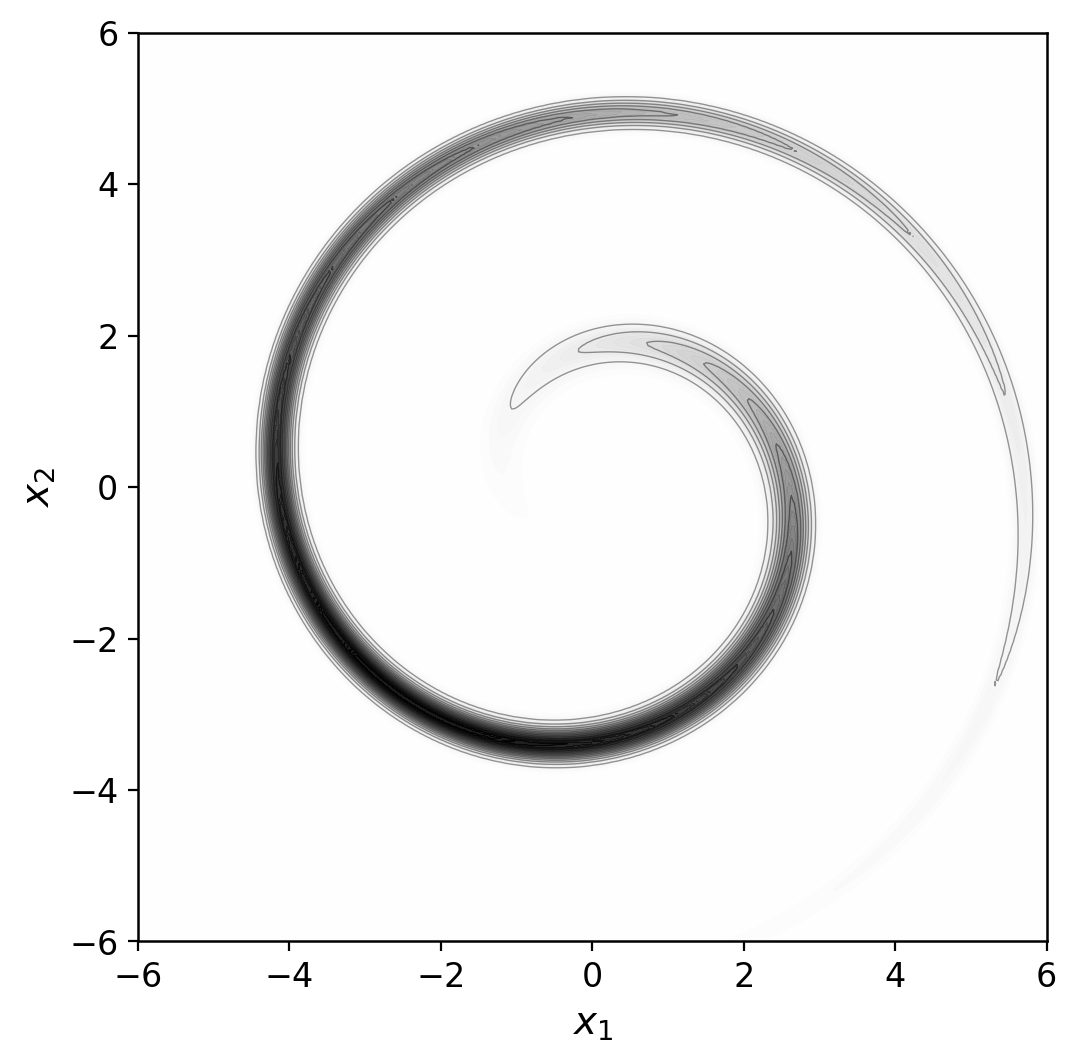

In [7]:
# Publication-quality likelihood contours (polar twist)
import sys
from pathlib import Path

reports_root = Path("../reports")
reports_root.mkdir(parents=True, exist_ok=True)
fig_dir = reports_root / "polar_twist"
fig_dir.mkdir(parents=True, exist_ok=True)

style_path = reports_root / "figure_style.py"
if style_path.exists() and str(reports_root) not in sys.path:
    sys.path.insert(0, str(reports_root))
try:
    from figure_style import apply_pub_style
    apply_pub_style()
except Exception:
    pass

grid_min = -6.0
grid_max = 6.0
grid_n = 300
grid = np.linspace(grid_min, grid_max, grid_n)
X1, X2 = np.meshgrid(grid, grid)
log_like = np.zeros_like(X1)
for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
        x_grid = np.array([X1[i, j], X2[i, j]])
        log_like[i, j] = log_likelihood_polar_twist(x_grid, y_obs, sigma=sigma_noise, alpha=alpha)
log_like -= log_like.max()
like = np.exp(log_like)

fig, ax = plt.subplots(1, 1, figsize=(6.5, 5.2), constrained_layout=True)
levels_fill = 50
levels_line = 14
ax.contourf(X1, X2, like, levels=levels_fill, cmap="Grays", alpha=0.9)
ax.contour(X1, X2, like, levels=levels_line, colors="black", linewidths=0.5, alpha=0.4)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
# ax.set_title("Polar twist likelihood contours")

def _fmt(val):
    return str(val).replace(".", "p")

config_tag = f"alpha{_fmt(alpha)}_sigma{_fmt(sigma_noise)}_prior{_fmt(prior_std)}_grid{grid_n}_seed{seed_mcmc}"
fig_path = fig_dir / f"likelihood_contours_polar_twist_{config_tag}.png"
fig.savefig(fig_path, bbox_inches="tight")
print(f"Saved {fig_path}")
plt.show()

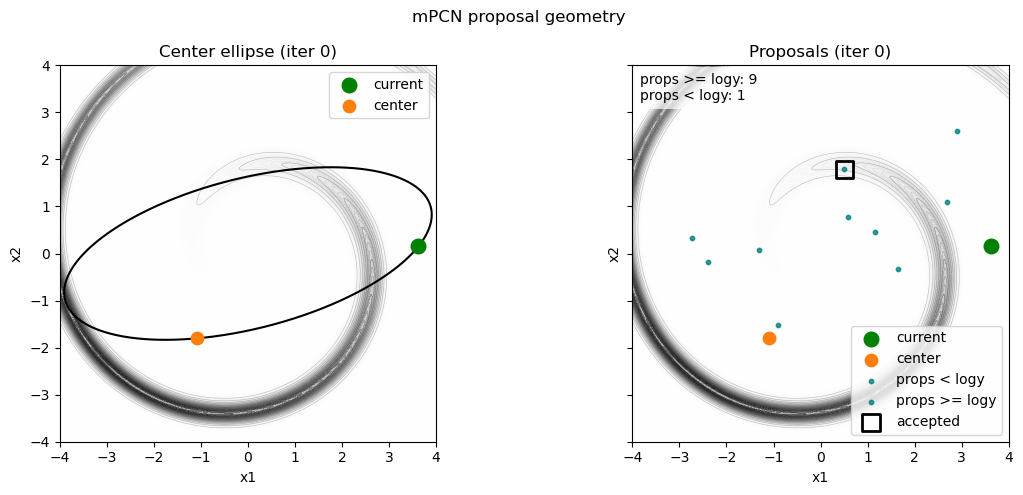

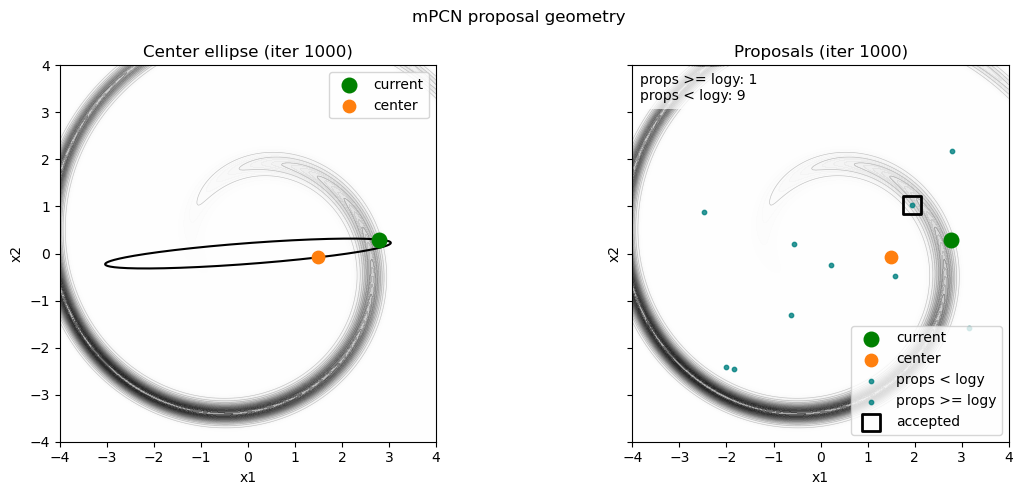

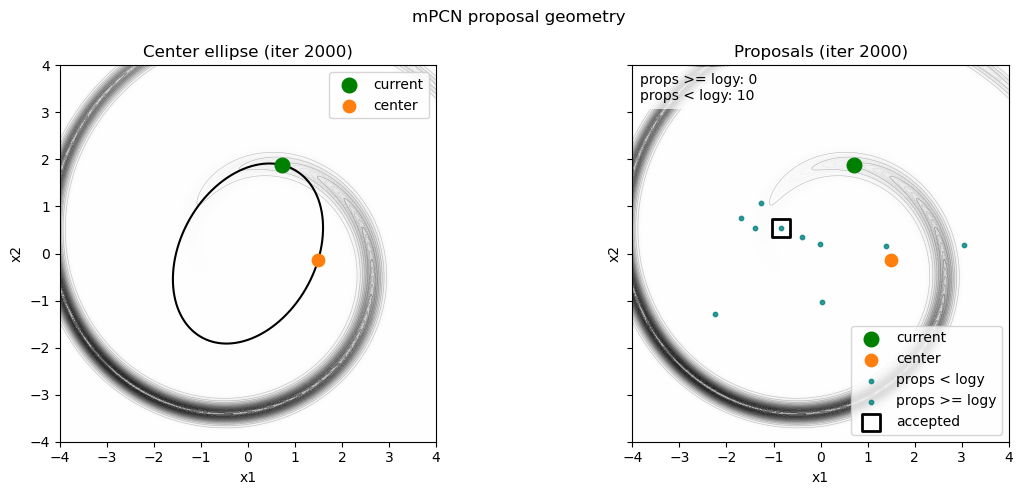

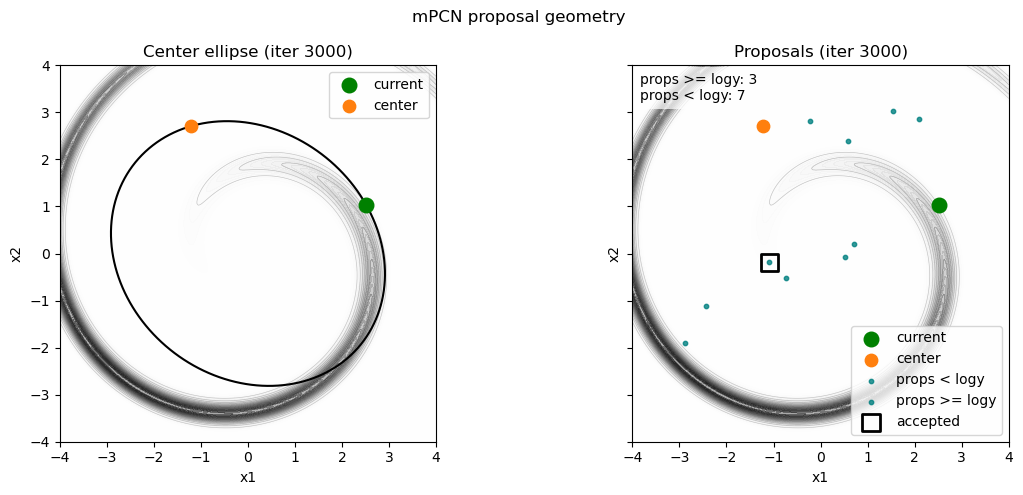

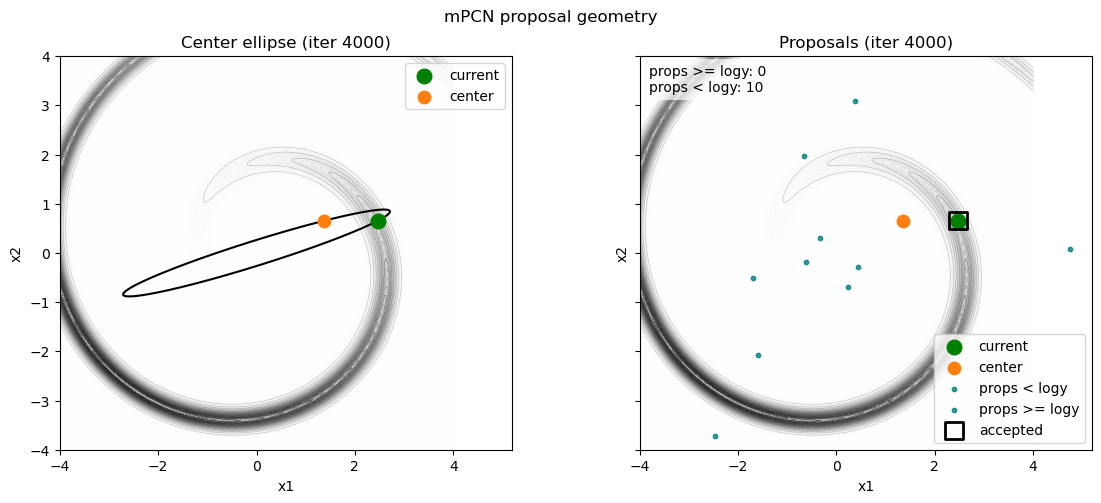

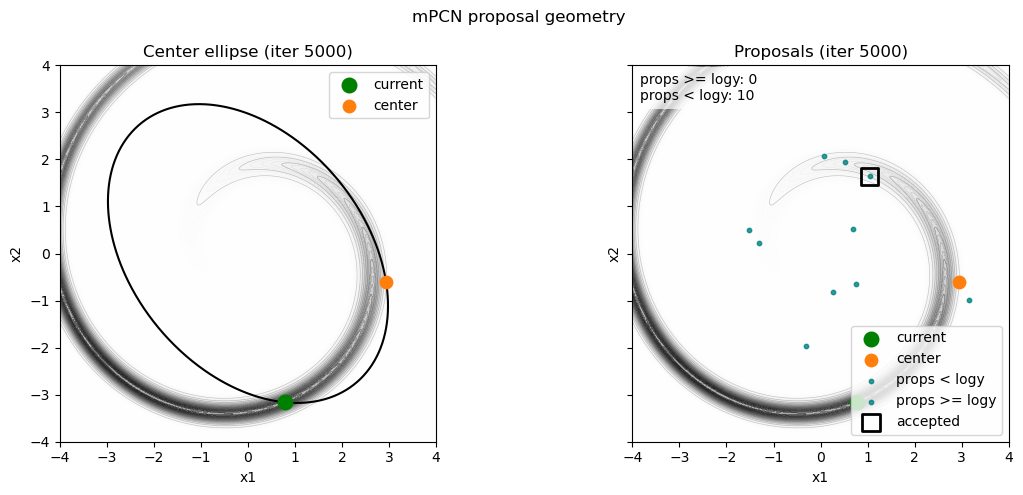

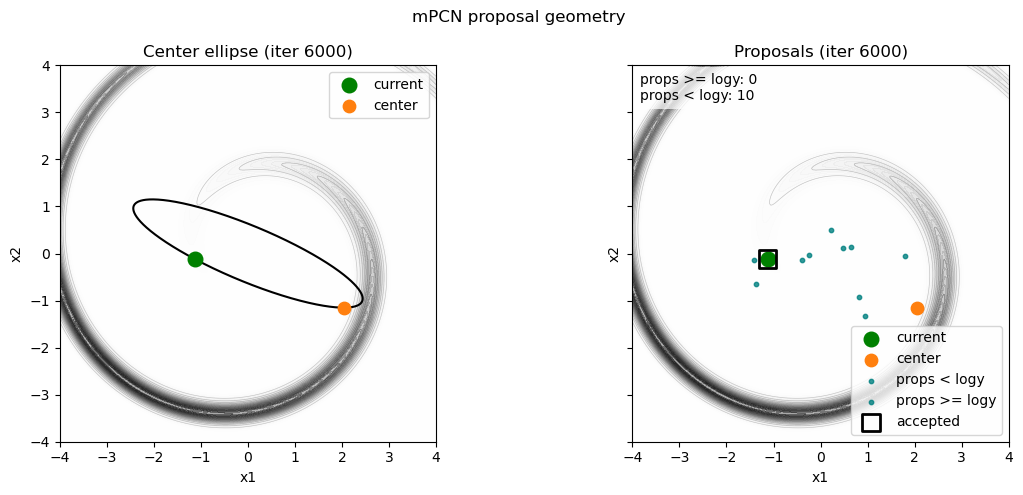

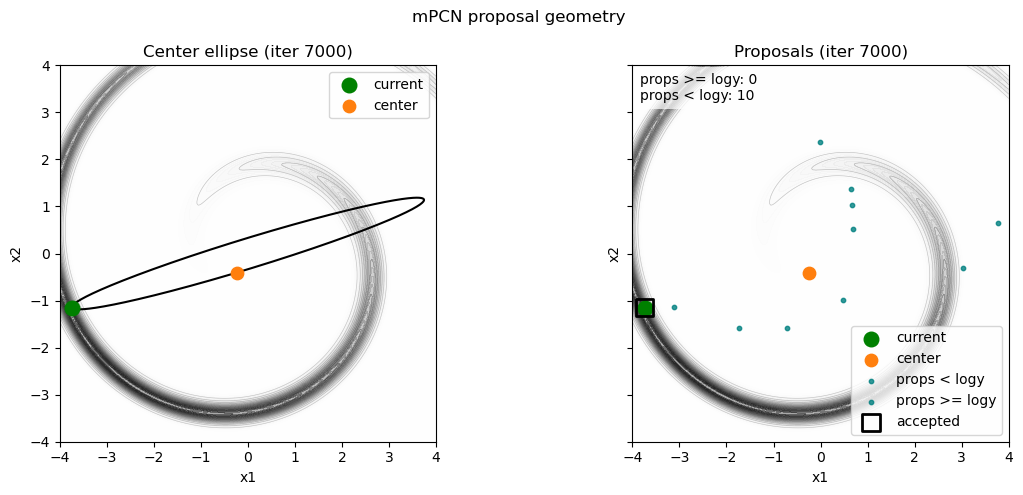

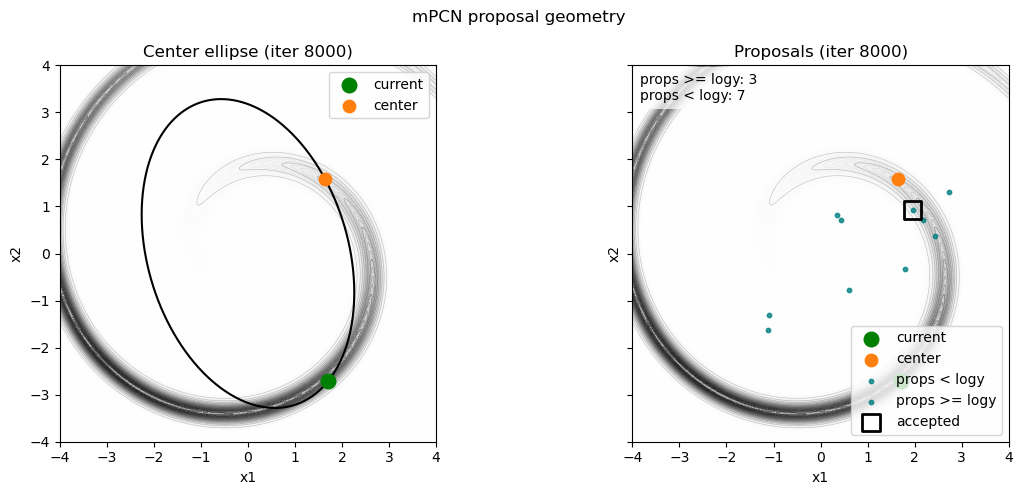

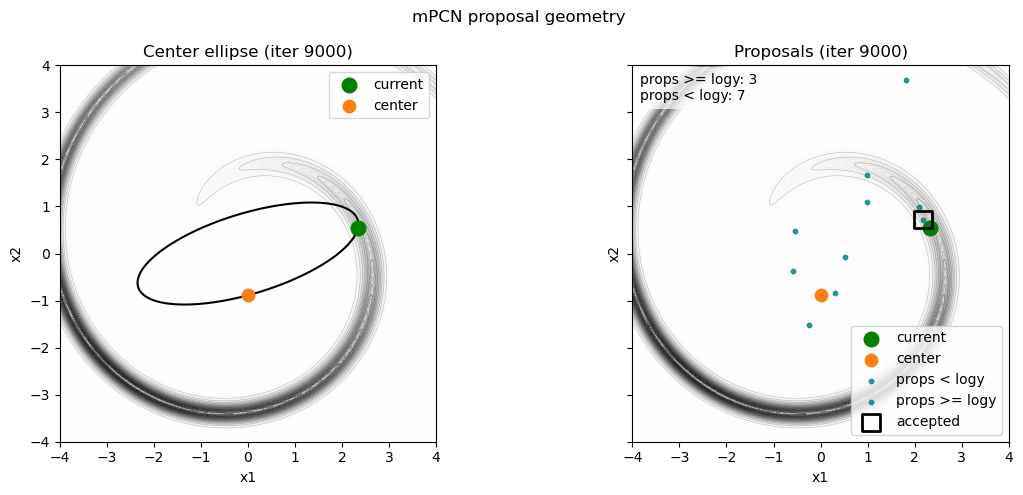

In [ ]:
# Proposal illustrations for selected iterations (separate diagnostic run)
plot_iters = [nr for nr in np.arange(0, 10000, 1000)]
plot_iters = sorted(set(plot_iters))
n_iters_diag = max(plot_iters) + 1
seed_mpcn_diag = 202
rng_diag = np.random.default_rng(seed_mpcn_diag)
x0_diag = x0.copy()

grid_min = -4.0
grid_max = 4.0
grid = np.linspace(grid_min, grid_max, 300)
X1, X2 = np.meshgrid(grid, grid)
log_like = np.zeros_like(X1)
for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
        x_grid = np.array([X1[i, j], X2[i, j]])
        log_like[i, j] = log_likelihood_polar_twist(x_grid, y_obs, sigma=sigma_noise, alpha=alpha)
log_like -= log_like.max()
like_density = np.exp(log_like)

theta = np.linspace(0.0, 2.0 * np.pi, 800)
levels_fill = 50
levels_line = 14

def plot_mpcn_snapshot(iter_idx, x, x_center, nu_c, props, candidates, logy, accepted_idx):
    mu = problem.prior_mean()
    ellipse = mu + np.cos(theta)[:, None] * (x - mu) + np.sin(theta)[:, None] * nu_c
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
    for ax in axes:
        ax.contourf(X1, X2, like_density, levels=levels_fill, cmap='Greys', alpha=0.35)
        ax.contour(X1, X2, like_density, levels=levels_line, colors='black', linewidths=0.5, alpha=0.2)
        ax.set_aspect('equal', adjustable='box')
        ax.set_xlabel('x1')
        ax.set_ylabel('x2')
        ax.grid(False)
    axes[0].plot(ellipse[:, 0], ellipse[:, 1], color='black', linewidth=1.5, zorder=2)
    axes[0].scatter([x[0]], [x[1]], color='green', s=110, marker='o', label='current', zorder=3)
    axes[0].scatter([x_center[0]], [x_center[1]], color='tab:orange', s=80, marker='o', label='center', zorder=3)
    axes[0].set_title(f'Center ellipse (iter {iter_idx})')
    axes[0].legend(loc='upper right')

    prop_log_like = np.array([problem.log_likelihood(p) for p in props])
    above = prop_log_like >= logy
    n_above = int(np.sum(above))
    n_below = int(props.shape[0] - n_above)
    axes[1].scatter([x[0]], [x[1]], color='green', s=110, marker='o', label='current', zorder=3)
    axes[1].scatter([x_center[0]], [x_center[1]], color='tab:orange', s=80, marker='o', label='center', zorder=3)
    axes[1].scatter(props[~above, 0], props[~above, 1], color='teal', s=10, alpha=0.8, label='props < logy', zorder=2)
    axes[1].scatter(props[above, 0], props[above, 1], color='teal', s=10, alpha=0.8, label='props >= logy', zorder=2)
    accepted_point = candidates[accepted_idx]
    axes[1].scatter([accepted_point[0]], [accepted_point[1]], facecolors='none', edgecolors='black',
                    s=160, marker='s', linewidths=2.0, label='accepted', zorder=4)
    axes[1].text(
        0.02,
        0.98,
        f'props >= logy: {n_above}\nprops < logy: {n_below}',
        transform=axes[1].transAxes,
        va='top',
        ha='left',
        fontsize=10,
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'),
    )
    axes[1].set_title(f'Proposals (iter {iter_idx})')
    axes[1].legend(loc='lower right')
    fig.suptitle('mPCN proposal geometry')
    fig.tight_layout()
    plt.show()

snapshots = {}
x = x0_diag.copy()
for t in range(n_iters_diag):
    log_l0 = problem.log_likelihood(x)
    logy = log_l0 + np.log(rng_diag.uniform())
    x_new, idx, diag = mpcn_step(
        x,
        problem,
        rng_diag,
        rho=rho,
        n_props=n_props,
        return_idx=True,
        return_diagnostics=True,
    )
    if t in plot_iters:
        snapshots[t] = (
            x.copy(),
            diag["x_center"].copy(),
            diag["nu_c"].copy(),
            diag["props"].copy(),
            diag["candidates"].copy(),
            logy,
            idx,
        )
    x = x_new

for t in plot_iters:
    x_snap, x_center_snap, nu_c_snap, props_snap, candidates_snap, logy_snap, idx_snap = snapshots[t]
    plot_mpcn_snapshot(t, x_snap, x_center_snap, nu_c_snap, props_snap, candidates_snap, logy_snap, idx_snap)

In [9]:
# Runtime + ESS/MSJD per minute
burn_in_metric = 500
max_lag = 500

def compute_msjd_per_param(chain):
    if chain.shape[0] < 2:
        return np.zeros(chain.shape[1])
    jumps = np.diff(chain, axis=0)
    msjd = np.mean(jumps * jumps, axis=0)
    return msjd

def compute_ess_per_param(chain, max_lag):
    if chain.shape[0] < 2:
        return np.zeros(chain.shape[1])
    variances = np.var(chain, axis=0)
    if np.all(variances == 0):
        return np.zeros(chain.shape[1])
    ess_vals = estimate_effective_sample_size(chain, max_lag=max_lag)
    ess_vals = np.asarray(ess_vals, dtype=float)
    ess_vals[variances == 0] = 0.0
    return ess_vals

def summarize_chain_metrics(chain, runtime_sec, label):
    post = chain[burn_in_metric:]
    ess_vals = compute_ess_per_param(post, max_lag=max_lag)
    msjd_vals = compute_msjd_per_param(post)
    ess_mean = float(np.nanmean(ess_vals)) if ess_vals.size else 0.0
    msjd_mean = float(np.nanmean(msjd_vals)) if msjd_vals.size else 0.0
    runtime_min = runtime_sec / 60.0
    ess_per_min = ess_mean / runtime_min if runtime_min > 0 else np.nan
    print(f'{label} runtime (min): {runtime_min:.2f}')
    print(f'{label} mean ESS: {ess_mean:.1f}')
    print(f'{label} mean MSJD: {msjd_mean:.4g}')
    print(f'{label} ESS per minute: {ess_per_min:.2f}')
    return {
        'runtime_sec': runtime_sec,
        'runtime_min': runtime_min,
        'ess_mean': ess_mean,
        'msjd_mean': msjd_mean,
        'ess_per_min': ess_per_min,
    }

metrics_mpcn = summarize_chain_metrics(chain_mpcn, runtime_mpcn_sec, f'mPCN (P={n_props})')
metrics_mess = None
if run_mess and chain_mess is not None:
    metrics_mess = summarize_chain_metrics(chain_mess, runtime_mess_sec, f'MESS (M={mess_M})')
else:
    print('Skipping MESS metrics (run_mess=False).')

Estimating ESS for each parameter.
mPCN (P=10) runtime (min): 0.04
mPCN (P=10) mean ESS: 11156.2
mPCN (P=10) mean MSJD: 3.591
mPCN (P=10) ESS per minute: 268265.28
Estimating ESS for each parameter.
MESS (M=10) runtime (min): 0.05
MESS (M=10) mean ESS: 7242.1
MESS (M=10) mean MSJD: 2.781
MESS (M=10) ESS per minute: 149103.84


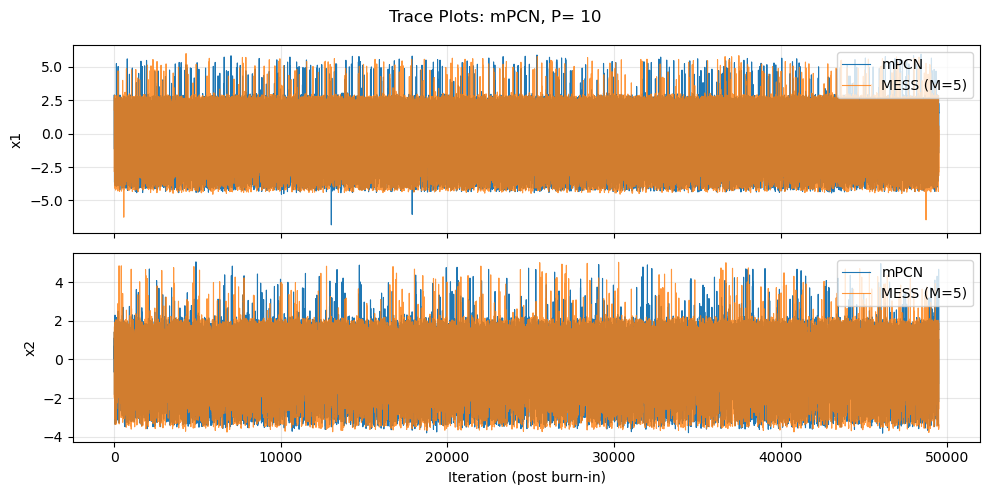

In [10]:
burn_in = 500
post_chain_mpcn = chain_mpcn[burn_in:]
post_chain_mess = chain_mess[burn_in:] if run_mess and chain_mess is not None else None

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(post_chain_mpcn[:, 0], color='tab:blue', linewidth=0.8, label='mPCN')
if post_chain_mess is not None:
    axes[0].plot(post_chain_mess[:, 0], color='tab:orange', linewidth=0.8, alpha=0.8, label='MESS (M=5)')
axes[0].set_ylabel('x1')
axes[0].grid(alpha=0.3)
axes[0].legend(loc='upper right')

axes[1].plot(post_chain_mpcn[:, 1], color='tab:blue', linewidth=0.8, label='mPCN')
if post_chain_mess is not None:
    axes[1].plot(post_chain_mess[:, 1], color='tab:orange', linewidth=0.8, alpha=0.8, label='MESS (M=5)')
axes[1].set_ylabel('x2')
axes[1].set_xlabel('Iteration (post burn-in)')
axes[1].grid(alpha=0.3)
axes[1].legend(loc='upper right')

fig.suptitle(f'Trace Plots: mPCN, P= {n_props}')
fig.tight_layout()
plt.show()

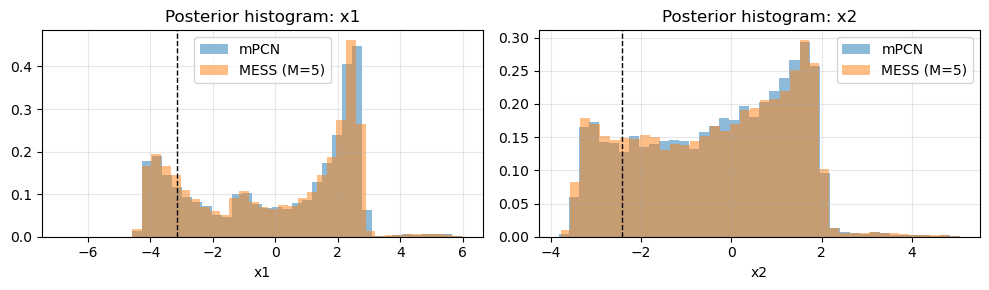

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
bins = 40
axes[0].hist(post_chain_mpcn[:, 0], bins=bins, density=True, color='tab:blue', alpha=0.5, label='mPCN')
if post_chain_mess is not None:
    axes[0].hist(post_chain_mess[:, 0], bins=bins, density=True, color='tab:orange', alpha=0.5, label='MESS (M=5)')
axes[0].axvline(prior_sample[0], color='black', linestyle='--', linewidth=1)
axes[0].set_title('Posterior histogram: x1')
axes[0].set_xlabel('x1')
axes[0].grid(alpha=0.3)
axes[0].legend(loc='best')

axes[1].hist(post_chain_mpcn[:, 1], bins=bins, density=True, color='tab:blue', alpha=0.5, label='mPCN')
if post_chain_mess is not None:
    axes[1].hist(post_chain_mess[:, 1], bins=bins, density=True, color='tab:orange', alpha=0.5, label='MESS (M=5)')
axes[1].axvline(prior_sample[1], color='black', linestyle='--', linewidth=1)
axes[1].set_title('Posterior histogram: x2')
axes[1].set_xlabel('x2')
axes[1].grid(alpha=0.3)
axes[1].legend(loc='best')

fig.tight_layout()
plt.show()

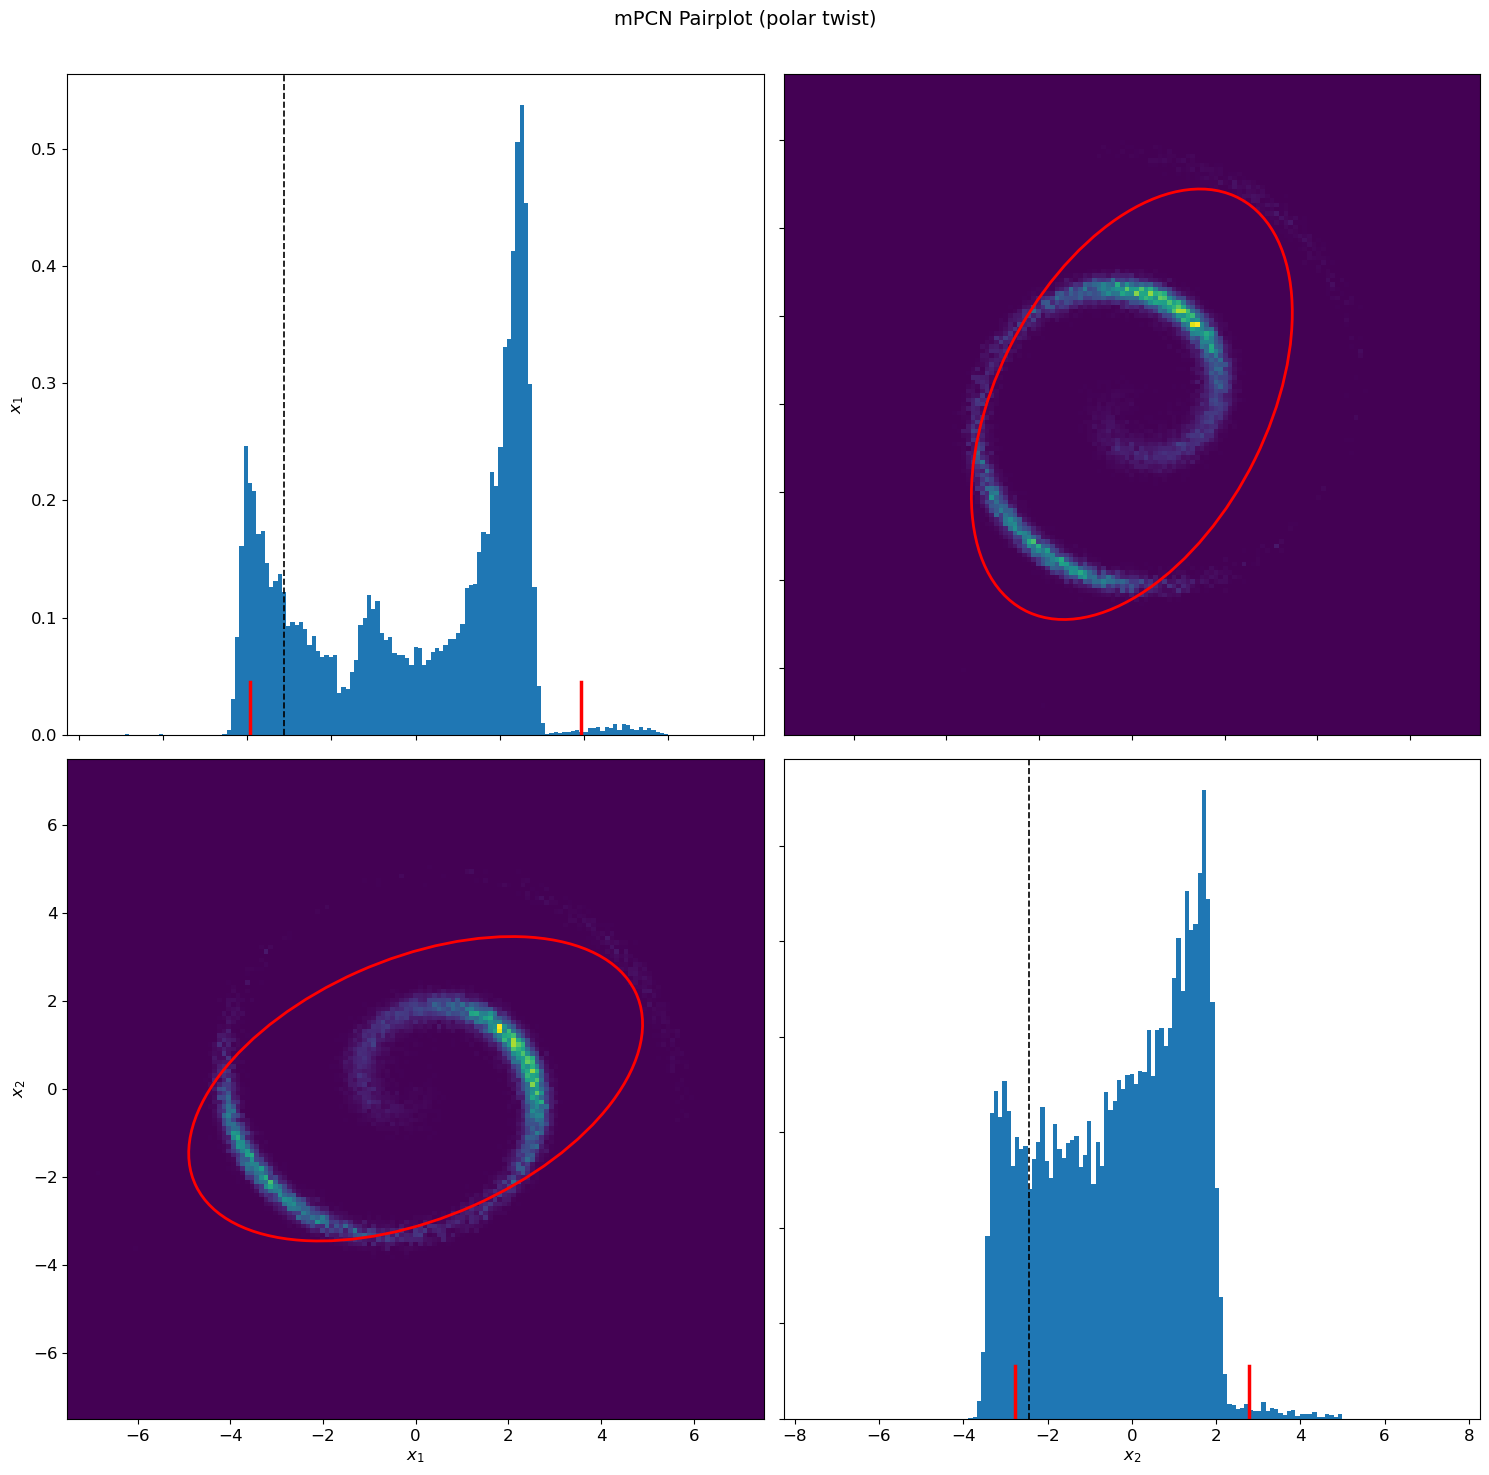

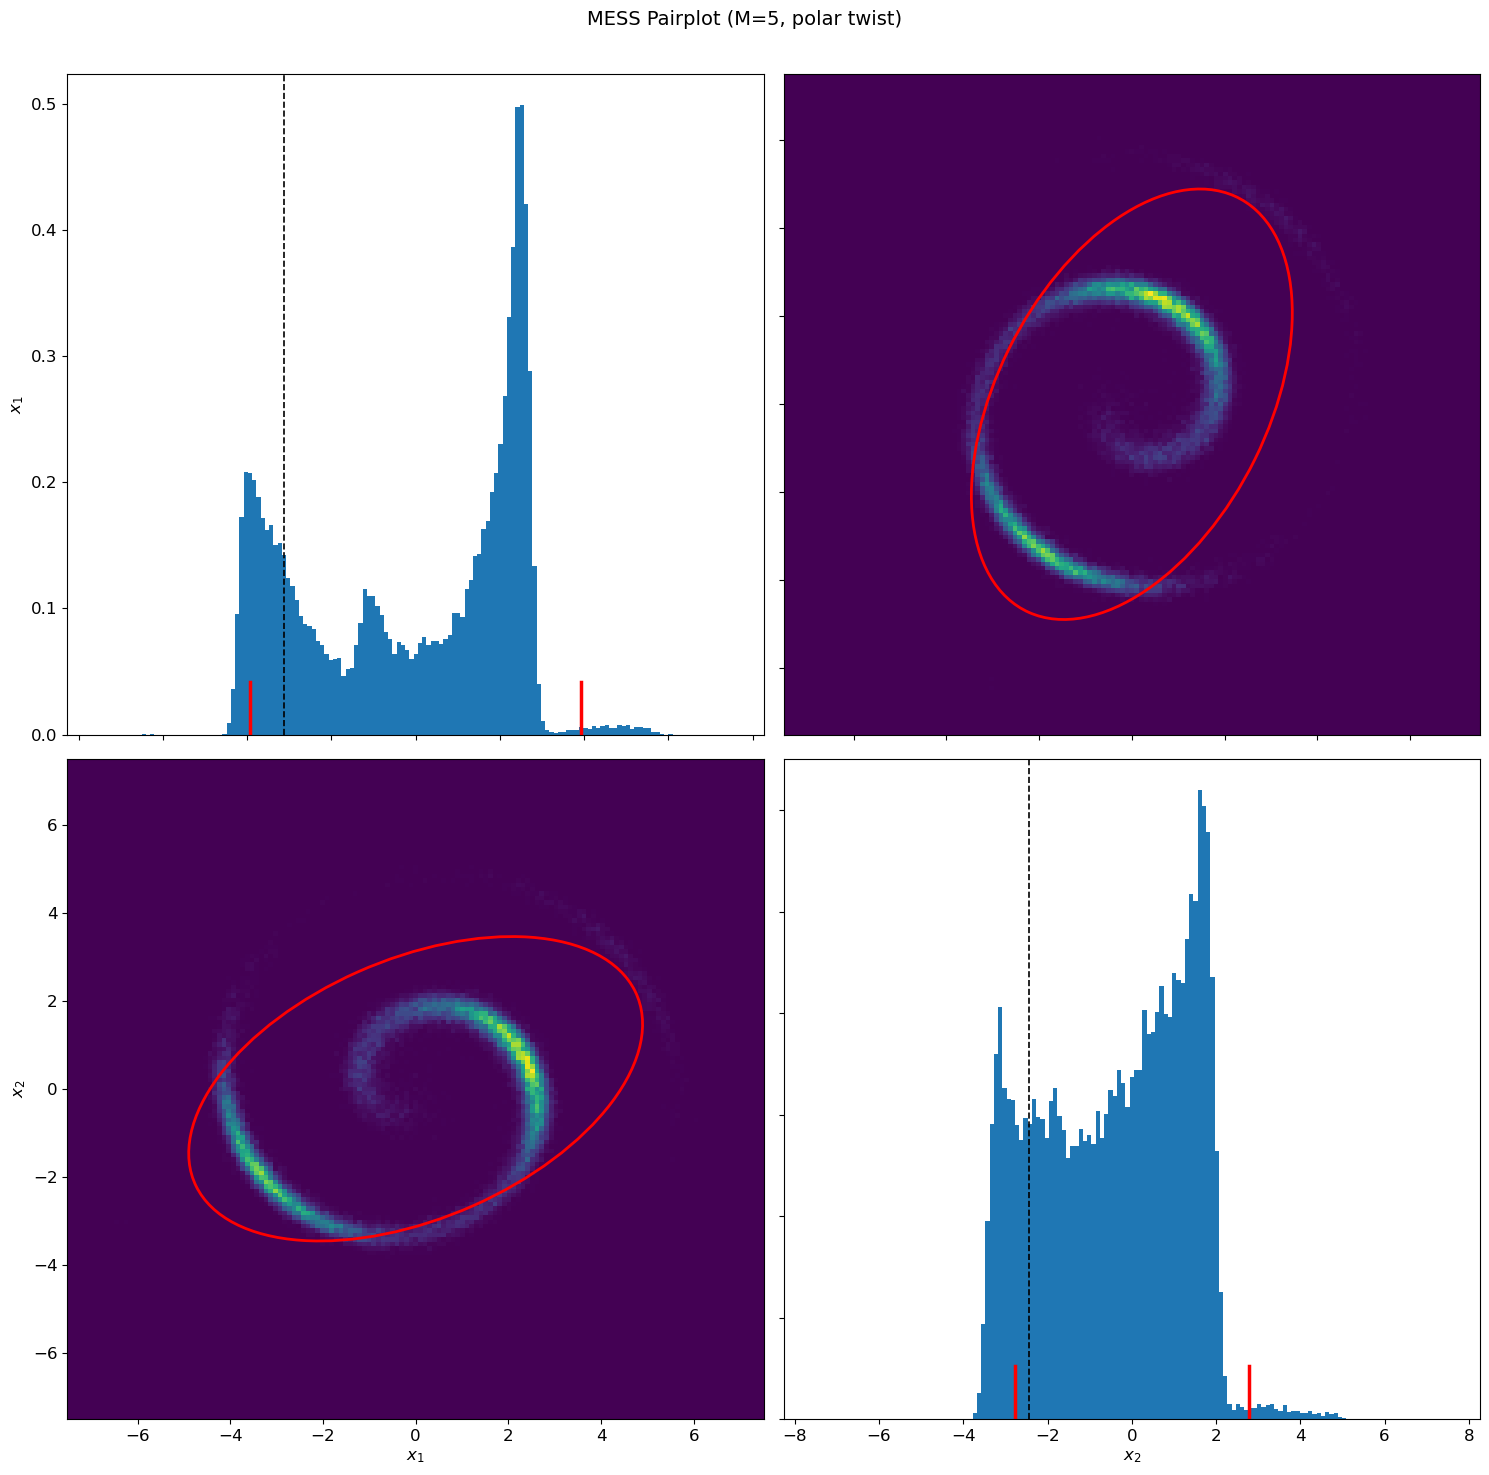

In [12]:
if post_chain_mess is not None:
    combined = np.vstack([post_chain_mpcn, post_chain_mess])
else:
    combined = post_chain_mpcn
R = 1.1 * np.max(np.abs(combined))
dr = 0.1

_ = make_hist_grid_comps(
    R=R,
    dr=dr,
    samples=post_chain_mpcn,
    comp_list=[0, 1],
    save_path=None,
    C=prior_cov,
    beta=0.95,
    hide_plot=False,
    label_map={0: '$x_1$', 1: '$x_2$'},
    font_size=12,
    title='mPCN Pairplot (polar twist)',
    true_values=prior_sample,
 )

if post_chain_mess is not None:
    _ = make_hist_grid_comps(
        R=R,
        dr=dr,
        samples=post_chain_mess,
        comp_list=[0, 1],
        save_path=None,
        C=prior_cov,
        beta=0.95,
        hide_plot=False,
        label_map={0: '$x_1$', 1: '$x_2$'},
        font_size=12,
        title='MESS Pairplot (M=5, polar twist)',
        true_values=prior_sample,
    )